
  TETHER (USDT) vs CARACAS BURSATIL (IBC) — IMPACT ANALYSIS

  Detected files:
    Caracas Bursatil : /content/Bursatil Historical Data.csv
    Tether USDT      : /content/Tether USDt Historical Data_crypto.csv

  Data loaded: 87 overlapping trading days (weekends dropped)
  Period : Jan 2019 → Mar 2026

      Date  USDT_Return  IBC_Return
2019-01-01      -0.0046      2.3868
2019-02-01       0.0005      0.9343
2019-03-01       0.0053     -0.1853
2019-04-01       0.0201      1.0747
2019-05-01      -0.0215     -0.1116
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
             Count     Mean      Std     Min      25%    50%     75%     Max
USDT_Return   87.0  0.00002  0.00367 -0.0215 -0.00060  0.000  0.0004  0.0201
IBC_Return    87.0  0.22028  0.42335 -0.9986  0.00155  0.116  0.3066  2.3868

  Pearson Correlation (USDT vs Bursatil IBC): 0.0893


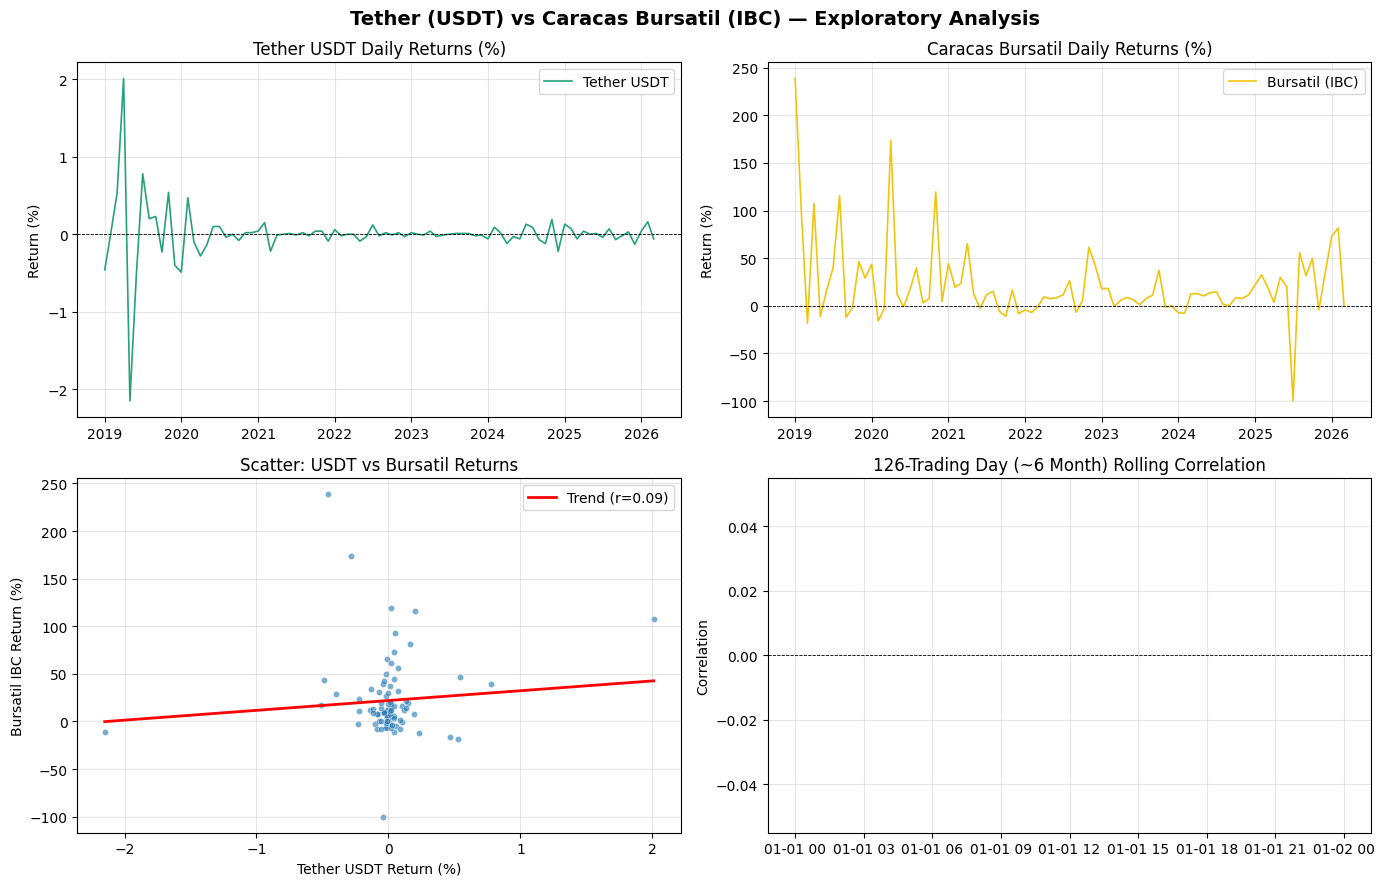


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average USDT Return (X̄) = 0.00184%
    Average Bursatil Return (Ȳ) = 22.02759%

  Step 4 — Slope β
    β = 10.2958
    → For every 1% rise in USDT, Bursatil changes by ~10.2958%

  Step 5 — Intercept α = 0.220087

  Step 6 — Regression Equation
    IBC_Return = 0.220087 + 10.2958 × USDT_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 12.4600
    t-statistic = 0.8263
    p-value     = 0.4109
    ✘ NOT significant — Fail to reject H₀

  Step 8 — Goodness of Fit
    R² = 0.0080  (0.80% of Bursatil variation explained by USDT)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:             IBC_Return   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.68

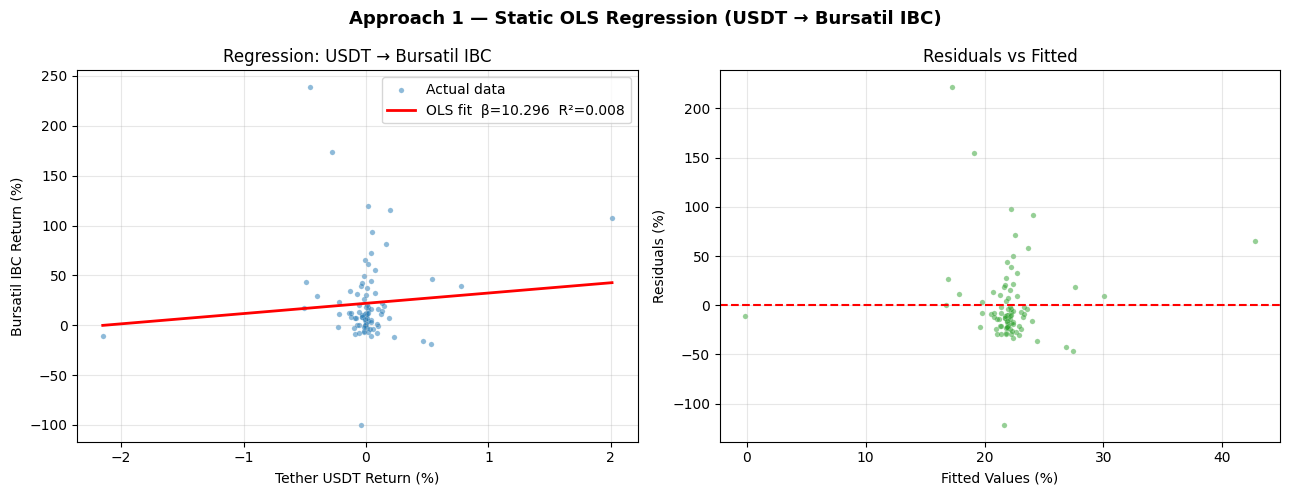


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    USDT Return               | ADF stat =  -3.442 | p = 0.0096 | ✔ Stationary
    Bursatil IBC Return       | ADF stat = -10.654 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of Bursatil Returns
    Lag-1 autocorrelation: 0.0387
    Lag-2 autocorrelation: -0.1044
    Low autocorrelation — lagged term adds robustness

  Step 4 & 5 — Building Dynamic Regression Model
    Model: IBC_t = α + β×USDT_t + γ×IBC_(t-1)

    Estimated equation:
    IBC_t = 0.18052 + 20.4237×USDT_t + 0.0588×IBC_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=20.4237  t=1.944  p=0.0553  ✘ Not significant
    Lag effect   (γ): coef=0.0588  t=0.650  p=0.5174  ✘ Not significant

    R² (dynamic model) = 0.0450
    Adj. R²            = 0.0219

  Step 7 — Granger Causality Test
    H₀: USDT returns do NOT Granger-cause Bursatil returns
    Sample size: 87 obs →

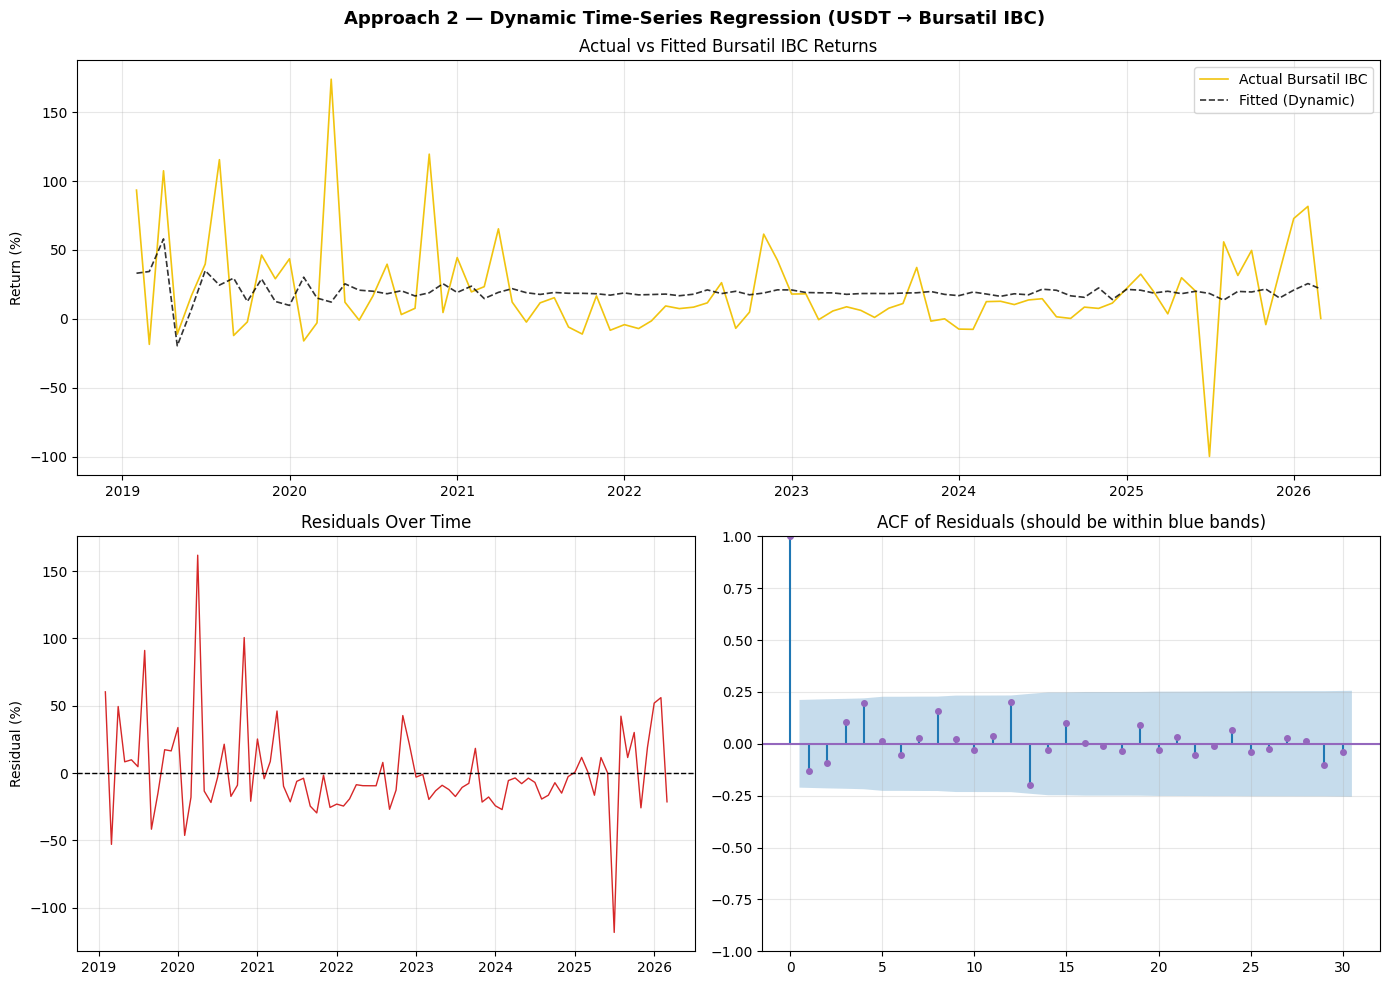


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                 10.2958                   20.4237
Lag Term (γ)                Not included                    0.0588
p-value (crypto)                  0.4109                    0.0553
R²                                0.0080                    0.0450
Accounts for Memory?                  No                       Yes


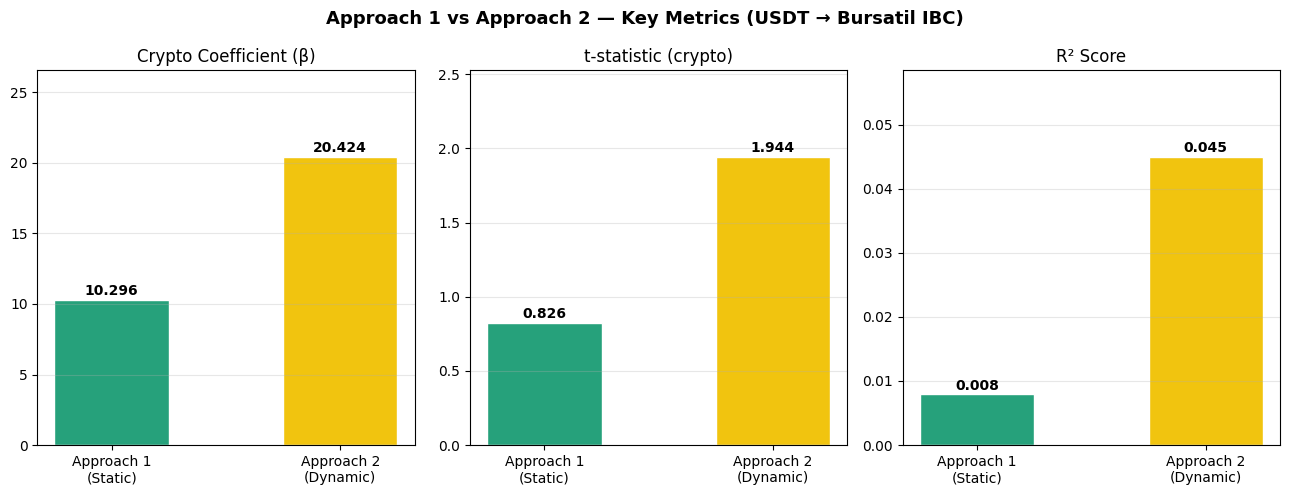


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Tether (USDT) impact on Caracas Bursatil (IBC) Index:

  ▸ Approach 1 (Static OLS):
      β = 10.2958 — a 1% USDT change correlates with ~10.296% IBC change
      R² = 0.0080
      Result: NOT SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 20.4237 — immediate effect after controlling for momentum
      γ = 0.0588 — 5.9% of prior period's IBC return persists
      R² = 0.0450
      Result: NOT SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS FOR VENEZUELA:
  1. The "Hyperinflationary Illusion": The Bursatil Index is denominated in the 
     Venezuelan Bolivar (VES). Due to historic hyperinflation, the nominal returns 
     of the IBC are astronomical (frequently hundreds or thousands of percent annually). 
     These gains reflect currency collapse, not genuine corporate valuation increases.
  2. The Stablecoin Peg Reality: The global price of USDT is mathematically pegged 
   

In [ ]:
# ============================================================
#   TETHER (USDT) vs CARACAS BURSATIL (IBC) — IMPACT ANALYSIS
# ============================================================

import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])


import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both Bursatil and Tether CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


IBC_FILE  = next((f for f in csv_files if "Bursatil" in os.path.basename(f) or "bursatil" in os.path.basename(f)), None)
USDT_FILE = next((f for f in csv_files if "Tether" in os.path.basename(f) or "tether" in os.path.basename(f)
                                        or "USDt" in os.path.basename(f) or "USDT" in os.path.basename(f)), None)


if IBC_FILE is None or USDT_FILE is None:
    remaining = [f for f in csv_files if f not in (IBC_FILE, USDT_FILE)]
    if IBC_FILE is None and remaining:
        IBC_FILE = remaining.pop(0)
    if USDT_FILE is None and remaining:
        USDT_FILE = remaining.pop(0)

if IBC_FILE is None or USDT_FILE is None:
    raise FileNotFoundError(
        "Could not identify both Bursatil and Tether CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'Bursatil' and 'Tether'/'USDt'."
    )

print("\n" + "=" * 65)
print("  TETHER (USDT) vs CARACAS BURSATIL (IBC) — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    Caracas Bursatil : {IBC_FILE}")
print(f"    Tether USDT      : {USDT_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()
    # Handle potentially different date formats gracefully
    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)


    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

usdt = load_and_clean(USDT_FILE, "USDT_Return")
ibc  = load_and_clean(IBC_FILE, "IBC_Return")


data = pd.merge(usdt, ibc, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "USDT_Return", "IBC_Return"]].head().to_string(index=False))
print("  ...")


print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["USDT_Return", "IBC_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(5).to_string())

corr = data["USDT_Return"].corr(data["IBC_Return"])
print(f"\n  Pearson Correlation (USDT vs Bursatil IBC): {corr:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Tether (USDT) vs Caracas Bursatil (IBC) — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["USDT_Return"] * 100, color="#26A17B", label="Tether USDT", linewidth=1.2) # Tether Green
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Tether USDT Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["IBC_Return"] * 100, color="#F1C40F", label="Bursatil (IBC)", linewidth=1.2) # Yellow accent for Venezuela
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Caracas Bursatil Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["USDT_Return"] * 100, data["IBC_Return"] * 100,
           alpha=0.6, color="#1f77b4", edgecolors="white", linewidth=0.4, s=20)

if data["USDT_Return"].std() > 1e-6:
    m, b = np.polyfit(data["USDT_Return"], data["IBC_Return"], 1)
    x_line = np.linspace(data["USDT_Return"].min(), data["USDT_Return"].max(), 100)
    ax.plot(x_line * 100, (m * x_line + b) * 100, color="red", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Tether USDT Return (%)")
ax.set_ylabel("Bursatil IBC Return (%)")
ax.set_title("Scatter: USDT vs Bursatil Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]

roll_corr = data["USDT_Return"].rolling(126).corr(data["IBC_Return"])
ax.plot(data["Date"], roll_corr, color="#C0392B", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["USDT_Return"]
Y = data["IBC_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average USDT Return (X̄) = {x_mean*100:.5f}%")
print(f"    Average Bursatil Return (Ȳ) = {y_mean*100:.5f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator if denominator != 0 else 0
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in USDT, Bursatil changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    IBC_Return = {alpha:.6f} + {beta:.4f} × USDT_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse.get("USDT_Return", np.nan)
t_stat    = ols_model.tvalues.get("USDT_Return", np.nan)
p_value   = ols_model.pvalues.get("USDT_Return", np.nan)

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")

if pd.notna(t_stat) and abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of Bursatil variation explained by USDT)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (USDT → Bursatil IBC)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#1f77b4", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Tether USDT Return (%)")
ax.set_ylabel("Bursatil IBC Return (%)")
ax.set_title("Regression: USDT → Bursatil IBC")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#2ca02c", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["USDT_Return"], "USDT Return"),
                     (data["IBC_Return"],  "Bursatil IBC Return")]:
    if series.std() > 1e-6:
        adf_result = adfuller(series.dropna())
        stat, pval = adf_result[0], adf_result[1]
        flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
        print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")
    else:
        print(f"    {name:25s} | Variance too low for reliable ADF test (USDT Peg behavior)")

print("\n  Step 3 — Autocorrelation of Bursatil Returns")
lag1_autocorr = data["IBC_Return"].autocorr(lag=1)
lag2_autocorr = data["IBC_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: IBC_t = α + β×USDT_t + γ×IBC_(t-1)")

data_dyn = data.copy()
data_dyn["IBC_Lag1"] = data_dyn["IBC_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["IBC_Return"]
X_dyn = sm.add_constant(data_dyn[["USDT_Return", "IBC_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params.get("USDT_Return", 0)
gamma_dyn = dyn_model.params.get("IBC_Lag1", 0)

print(f"\n    Estimated equation:")
print(f"    IBC_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×USDT_t + {gamma_dyn:.4f}×IBC_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["USDT_Return", "IBC_Lag1"]:
    if var in dyn_model.tvalues:
        t  = dyn_model.tvalues[var]
        p  = dyn_model.pvalues[var]
        label = "Crypto effect (β)" if var == "USDT_Return" else "Lag effect   (γ)"
        sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
        print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: USDT returns do NOT Granger-cause Bursatil returns")
granger_data = data[["IBC_Return", "USDT_Return"]].dropna()


if granger_data["USDT_Return"].var() > 1e-8:
    max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
    granger_maxlag    = min(5, max_allowable_lag)
    print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
    try:
        gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)
        for lag, res in gc_results.items():
            f_stat = res[0]["ssr_ftest"][0]
            p_gc   = res[0]["ssr_ftest"][1]
            flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
            print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")
    except Exception as e:
        print(f"    Granger Causality failed (likely due to insufficient variance in USDT): {e}")
else:
    print("    Skipping Granger Causality due to near-zero variance in USDT (stablecoin peg).")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (USDT → Bursatil IBC)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#F1C40F", linewidth=1.2, label="Actual Bursatil IBC")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted Bursatil IBC Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#d62728", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#9467bd", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

p_val_static  = p_value if pd.notna(p_value) else 1.0
p_val_dynamic = dyn_model.pvalues.get("USDT_Return", 1.0)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_val_static:.4f}", f"{p_val_dynamic:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (USDT → Bursatil IBC)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat if pd.notna(t_stat) else 0, dyn_model.tvalues.get("USDT_Return", 0)),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#26A17B", "#F1C40F"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals if pd.notna(v)),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)


    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_val_static < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if p_val_dynamic < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Tether (USDT) impact on Caracas Bursatil (IBC) Index:

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% USDT change correlates with ~{beta:.3f}% IBC change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's IBC return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS FOR VENEZUELA:
  1. The "Hyperinflationary Illusion": The Bursatil Index is denominated in the
     Venezuelan Bolivar (VES). Due to historic hyperinflation, the nominal returns
     of the IBC are astronomical (frequently hundreds or thousands of percent annually).
     These gains reflect currency collapse, not genuine corporate valuation increases.
  2. The Stablecoin Peg Reality: The global price of USDT is mathematically pegged
     to $1.00 USD. Trying to regress the explosive, hyperinflation-driven movements
     of the Venezuelan stock market against the flat-lined returns of a US Dollar
     stablecoin guarantees a "Not Significant" relationship.
  3. Tether as the Real Economy: While global USDT prices don't drive the IBC,
     USDT operates as the de facto currency for much of Venezuela's shadow economy
     to bypass the Bolivar's depreciation. However, this is a parallel economic
     reality entirely disconnected from the institutional stock market.
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)